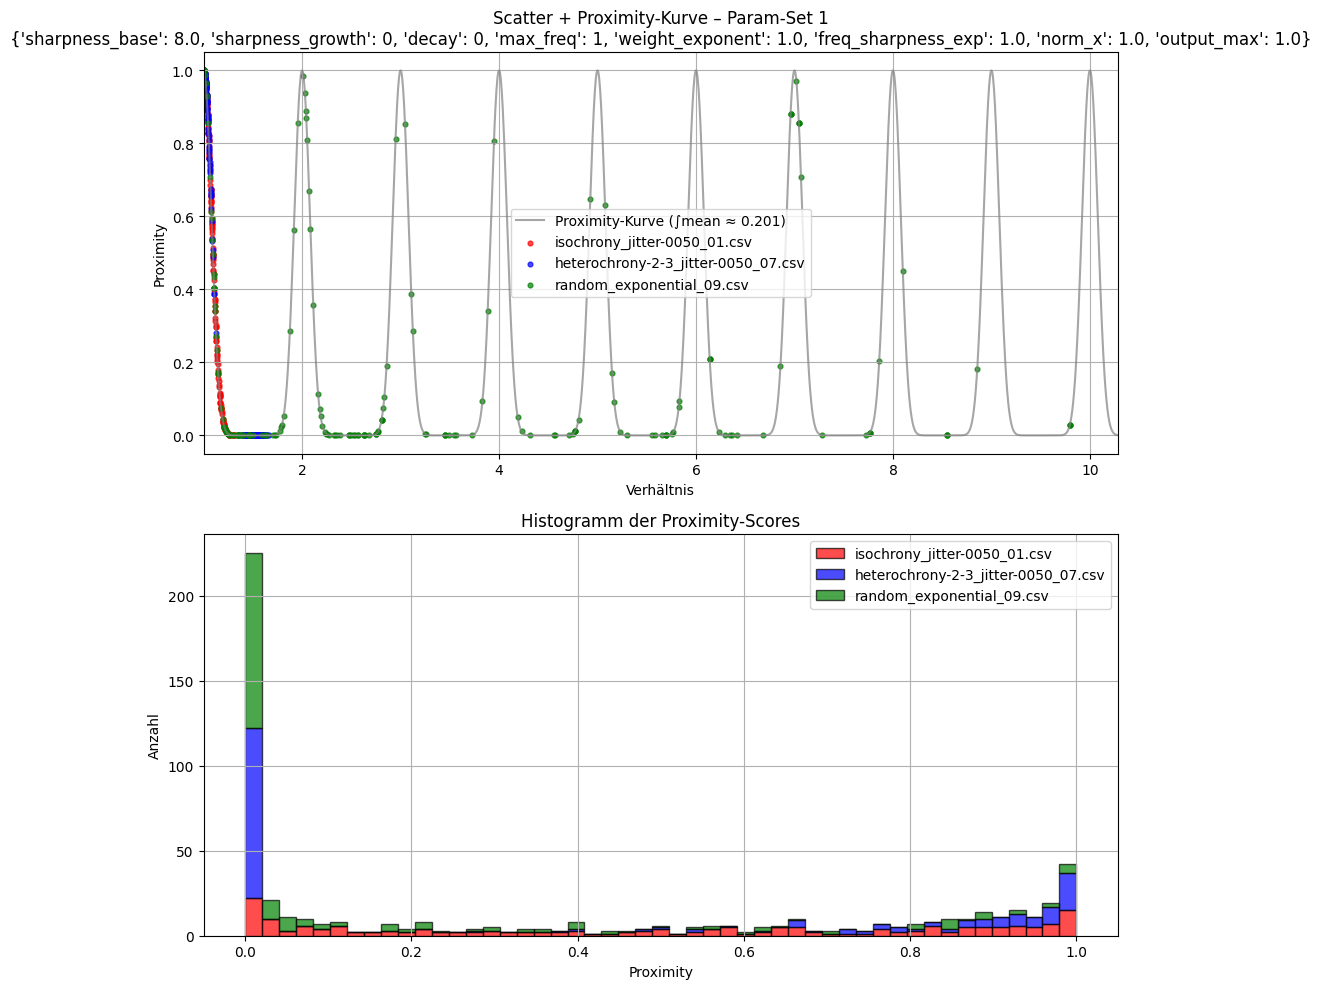

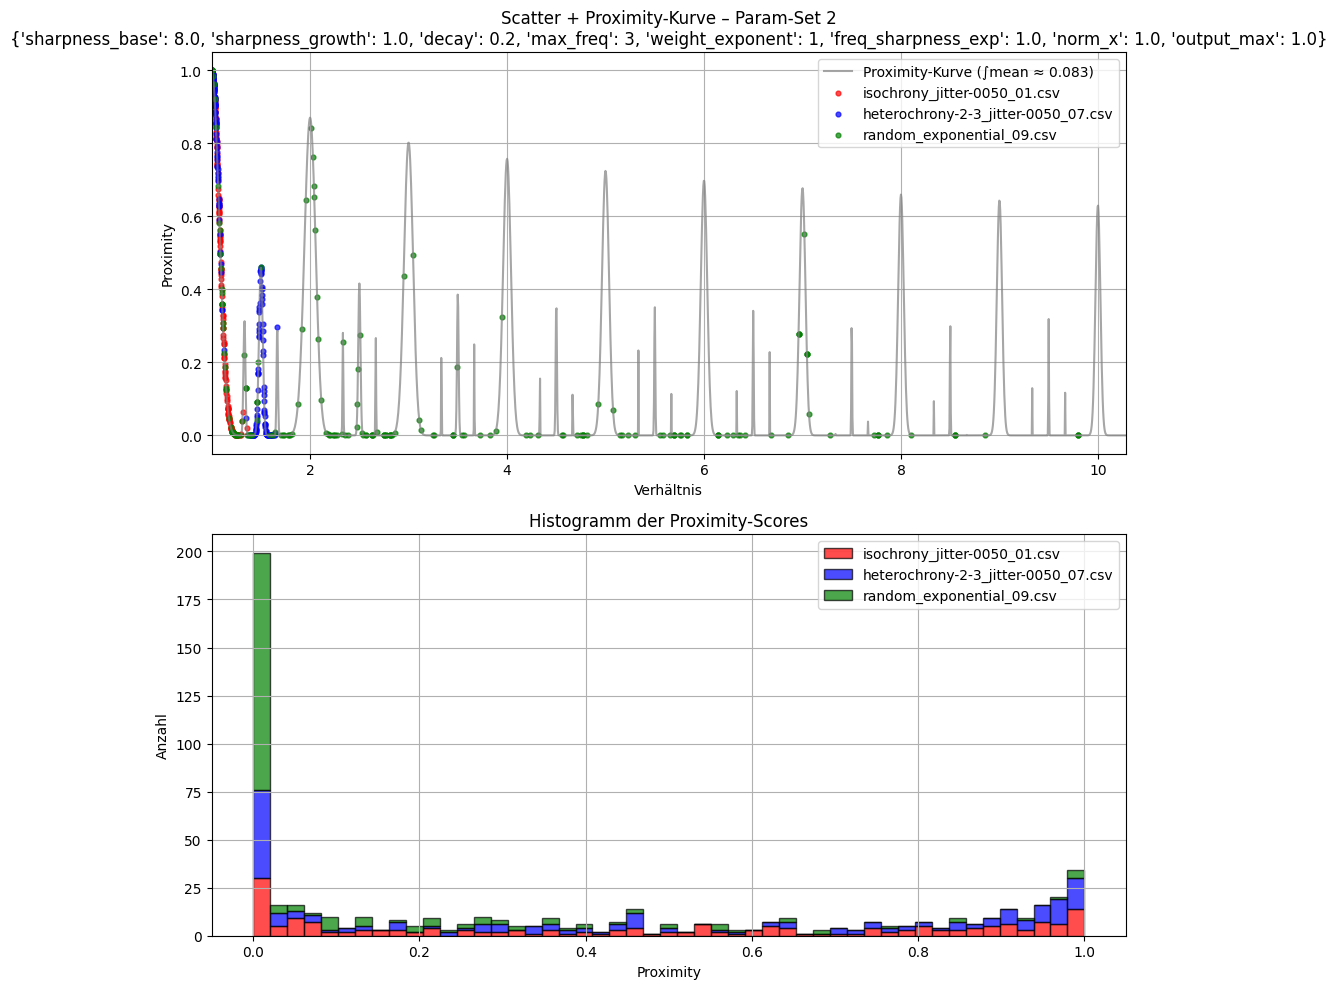

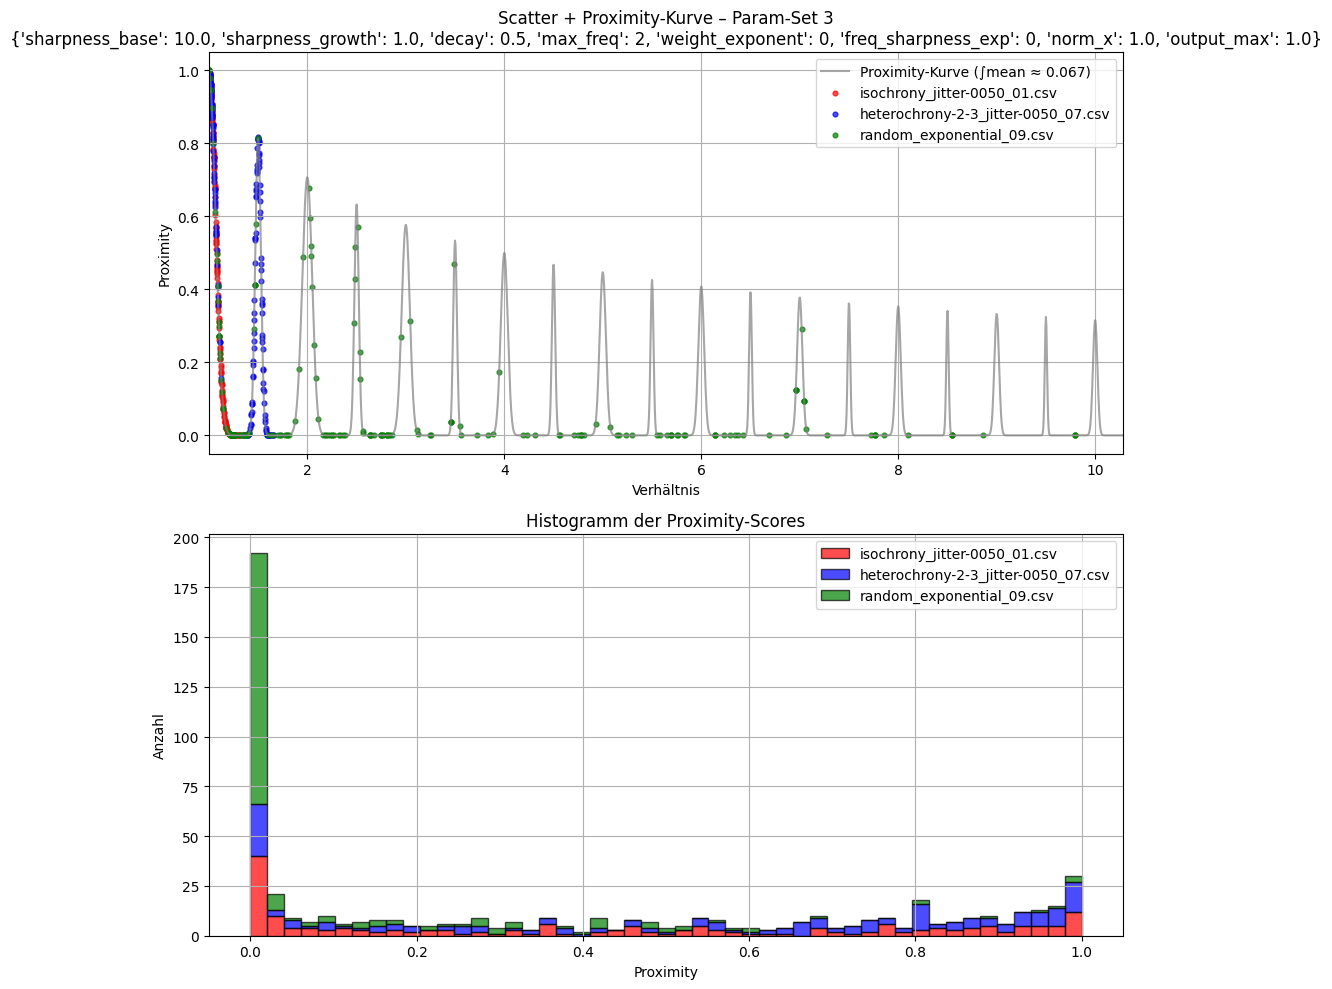

In [13]:
# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# Mehrere Parameter-Sets ausprobieren
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import simpson
from fractions import Fraction

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_exp)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Daten einlesen
# =============================
PAIR_THRESHOLD = 0.01
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats/")
filenames = ["isochrony_jitter-0050_01.csv",
             "heterochrony-2-3_jitter-0050_07.csv",
             "random_exponential_09.csv"]
colors = ["red", "blue", "green"]

# =============================
# 4) Verschiedene Parameter-Sets definieren
# =============================
param_sets = [
    dict(sharpness_base=8.0, sharpness_growth=0, decay=0,
         max_freq=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=8.0, sharpness_growth=1.0, decay=0.2,
         max_freq=3, weight_exponent=1, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=1.0, decay=0.5,
         max_freq=2, weight_exponent=0, freq_sharpness_exp=0,
         norm_x=1.0, output_max=1.0)
]

# =============================
# 5) Für jedes Param-Set analysieren & plotten
# =============================
for idx, params in enumerate(param_sets, start=1):
    dfs = []
    for fname in filenames:
        seq_path = base_dir / fname
        if not seq_path.exists():
            raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")
        df = pd.read_csv(seq_path)
        iois = df["IOI"].dropna().values
        df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
        df_pairs["source"] = fname
        dfs.append(df_pairs)

    df_all = pd.concat(dfs, ignore_index=True)

    # Plots
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # --- Scatter + Proximity-Kurve ---
    x_min = max(1.0, df_all["ratio"].min() * 0.95)
    x_max = df_all["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
    mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

    axes[0].plot(x_range, y_curve,
                 label=f"Proximity-Kurve (∫mean ≈ {mean_prox:.3f})",
                 alpha=0.7, color="gray")

    for fname, color in zip(filenames, colors):
        df_seq = df_all[df_all["source"] == fname]
        axes[0].scatter(df_seq["ratio"], df_seq["proximity"],
                        s=12, alpha=0.7, color=color, label=f"{fname}")

    axes[0].set_title(f"Scatter + Proximity-Kurve – Param-Set {idx}\n{params}")
    axes[0].set_xlabel("Verhältnis")
    axes[0].set_ylabel("Proximity")
    axes[0].set_xlim(x_min, x_max)
    axes[0].legend()
    axes[0].grid(True)

    # --- Histogramm ---
    bins = np.linspace(0, 1, 50)
    axes[1].hist(
        [df_all[df_all["source"] == fname]["proximity"].values for fname in filenames],
        bins=bins, stacked=True,
        label=filenames, color=colors,
        alpha=0.7, edgecolor="black"
    )
    axes[1].set_title("Histogramm der Proximity-Scores")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Anzahl")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()



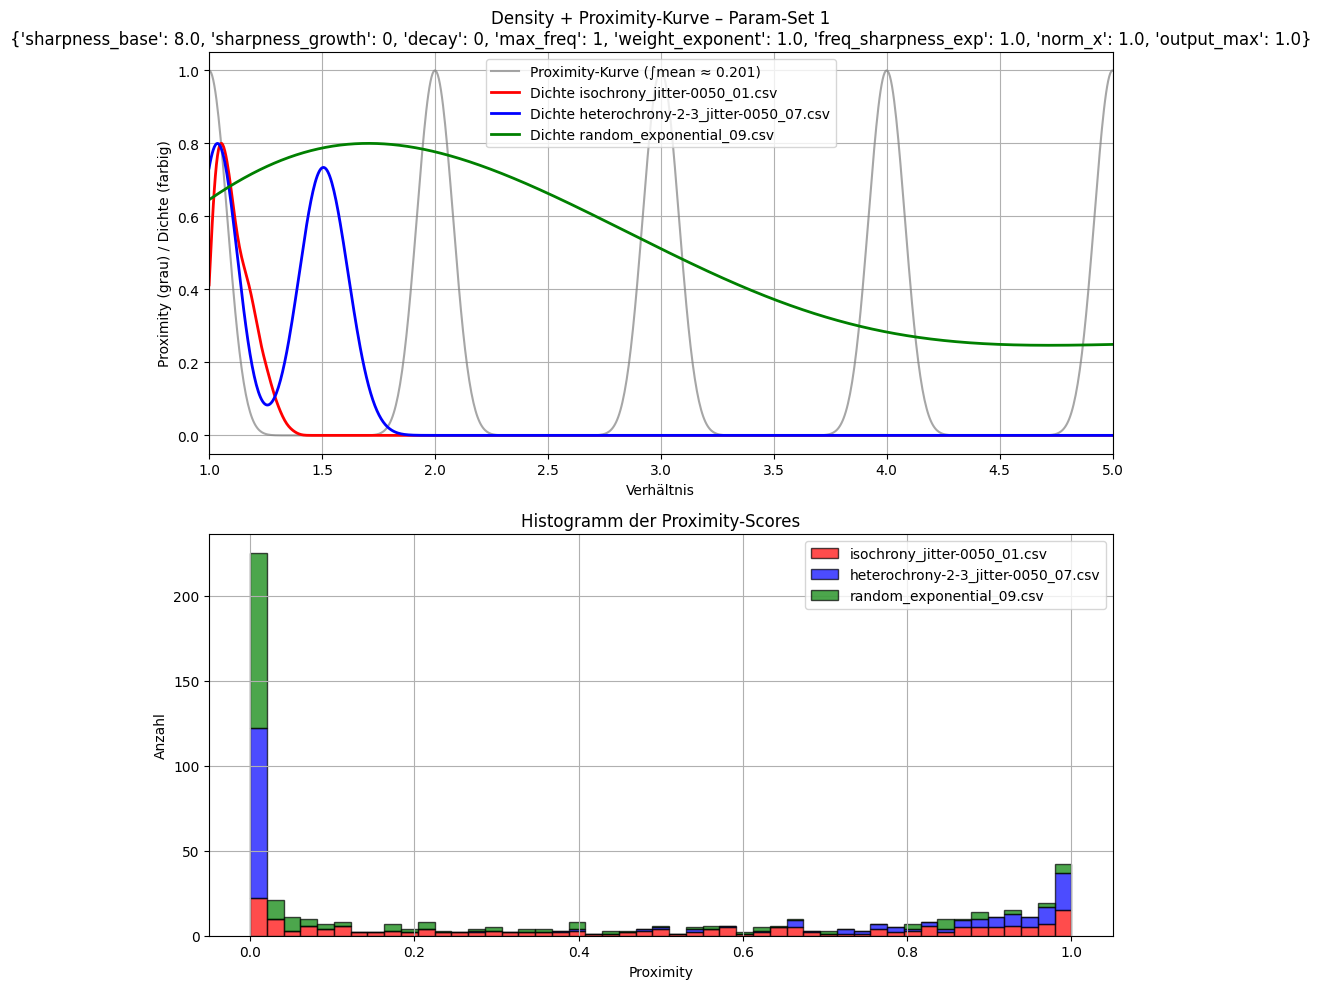

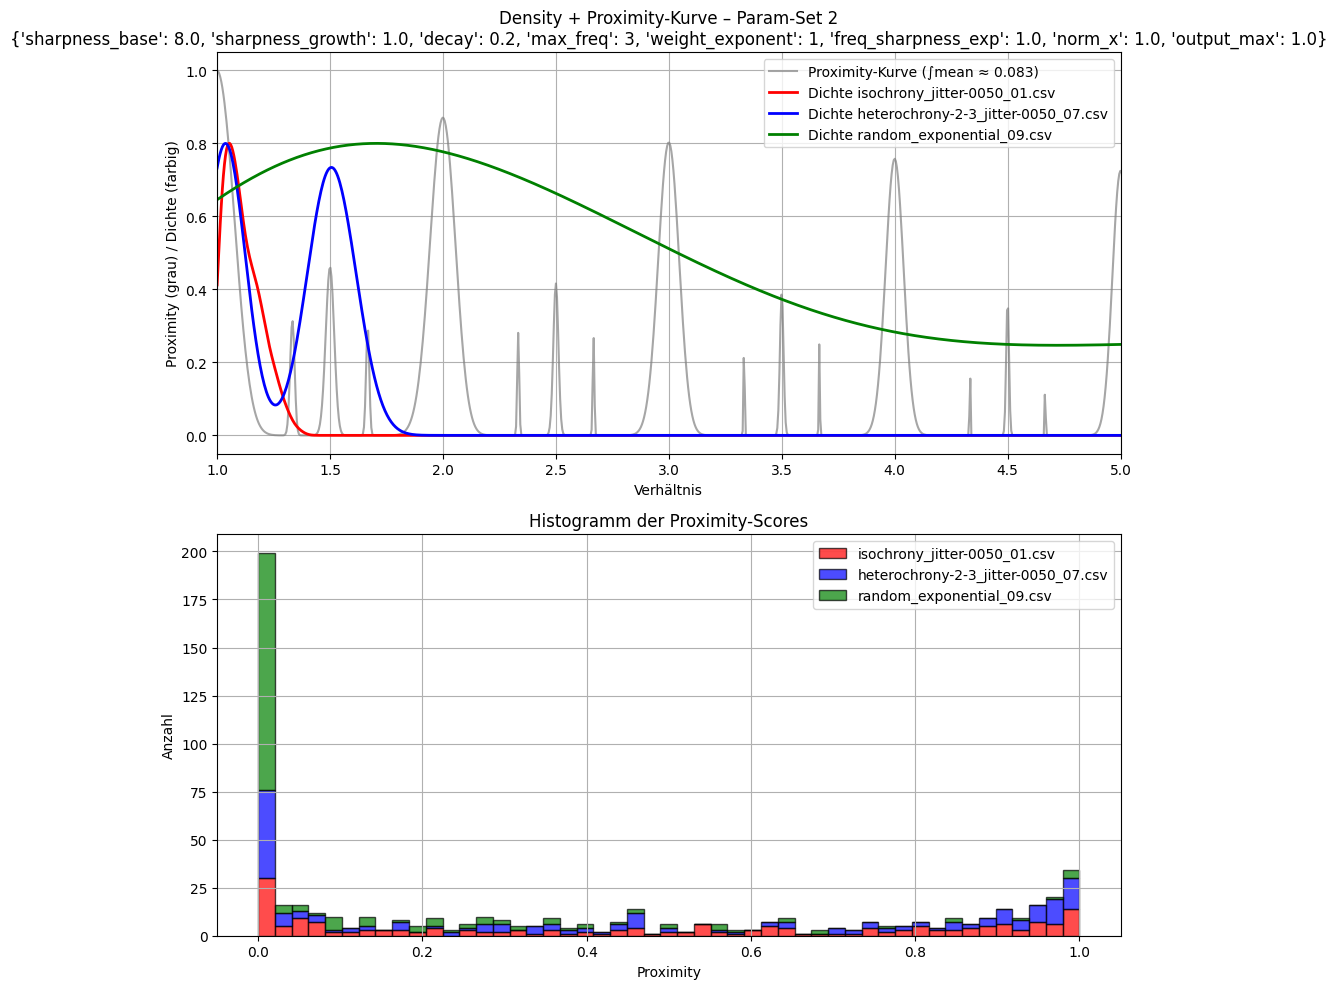

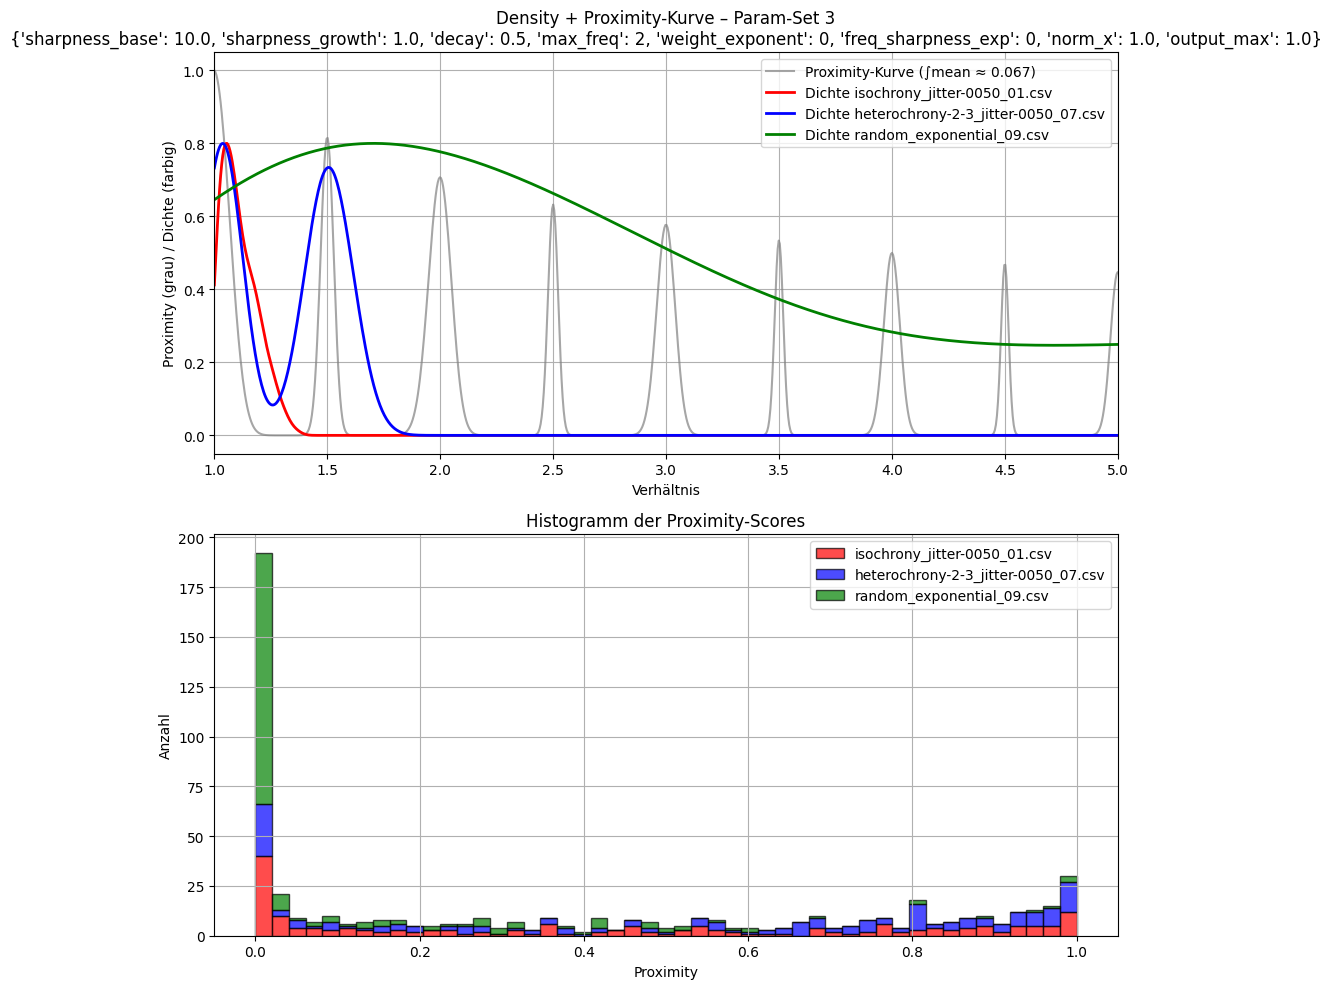

In [19]:
# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# Mehrere Parameter-Sets ausprobieren
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import simpson
from fractions import Fraction
from scipy.stats import gaussian_kde

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_exp)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Daten einlesen
# =============================
PAIR_THRESHOLD = 0.01
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats/")
filenames = ["isochrony_jitter-0050_01.csv",
             "heterochrony-2-3_jitter-0050_07.csv",
             "random_exponential_09.csv"] 
colors = ["red", "blue", "green"]

# =============================
# 4) Verschiedene Parameter-Sets definieren
# =============================
param_sets = [
    dict(sharpness_base=8.0, sharpness_growth=0, decay=0,
         max_freq=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=8.0, sharpness_growth=1.0, decay=0.2,
         max_freq=3, weight_exponent=1, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=1.0, decay=0.5,
         max_freq=2, weight_exponent=0, freq_sharpness_exp=0,
         norm_x=1.0, output_max=1.0)
]
# =============================
# 5) Für jedes Param-Set analysieren & plotten
# =============================
for idx, params in enumerate(param_sets, start=1):
    dfs = []
    for fname in filenames:
        seq_path = base_dir / fname
        if not seq_path.exists():
            raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")
        df = pd.read_csv(seq_path)
        iois = df["IOI"].dropna().values
        df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
        df_pairs["source"] = fname
        dfs.append(df_pairs)

    df_all = pd.concat(dfs, ignore_index=True)

    # Plots
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # --- Densityplot + Proximity-Kurve ---
    x_min = max(1.0, df_all["ratio"].min() * 0.95)
    x_max = df_all["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
    mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

    # Proximity-Kurve
    axes[0].plot(x_range, y_curve,
                 label=f"Proximity-Kurve (∫mean ≈ {mean_prox:.3f})",
                 alpha=0.7, color="gray")

    # Density-Plots für Ratios
    for fname, color in zip(filenames, colors):
        df_seq = df_all[df_all["source"] == fname]
        ratios = df_seq["ratio"].values
        if len(ratios) > 1:  # KDE braucht >1 Datenpunkte
            kde = gaussian_kde(ratios)
            y_kde = kde(x_range)
            # Normieren für bessere Vergleichbarkeit
            y_kde = y_kde / y_kde.max() * y_curve.max() * 0.8
            axes[0].plot(x_range, y_kde, color=color, label=f"Dichte {fname}", lw=2)

    axes[0].set_title(f"Density + Proximity-Kurve – Param-Set {idx}\n{params}")
    axes[0].set_xlabel("Verhältnis")
    axes[0].set_ylabel("Proximity (grau) / Dichte (farbig)")
    axes[0].set_xlim(1, 5)
    axes[0].legend()
    axes[0].grid(True)

    # --- Histogramm ---
    bins = np.linspace(0, 1, 50)
    axes[1].hist(
        [df_all[df_all["source"] == fname]["proximity"].values for fname in filenames],
        bins=bins, stacked=True,
        label=filenames, color=colors,
        alpha=0.7, edgecolor="black"
    )
    axes[1].set_title("Histogramm der Proximity-Scores")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Anzahl")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


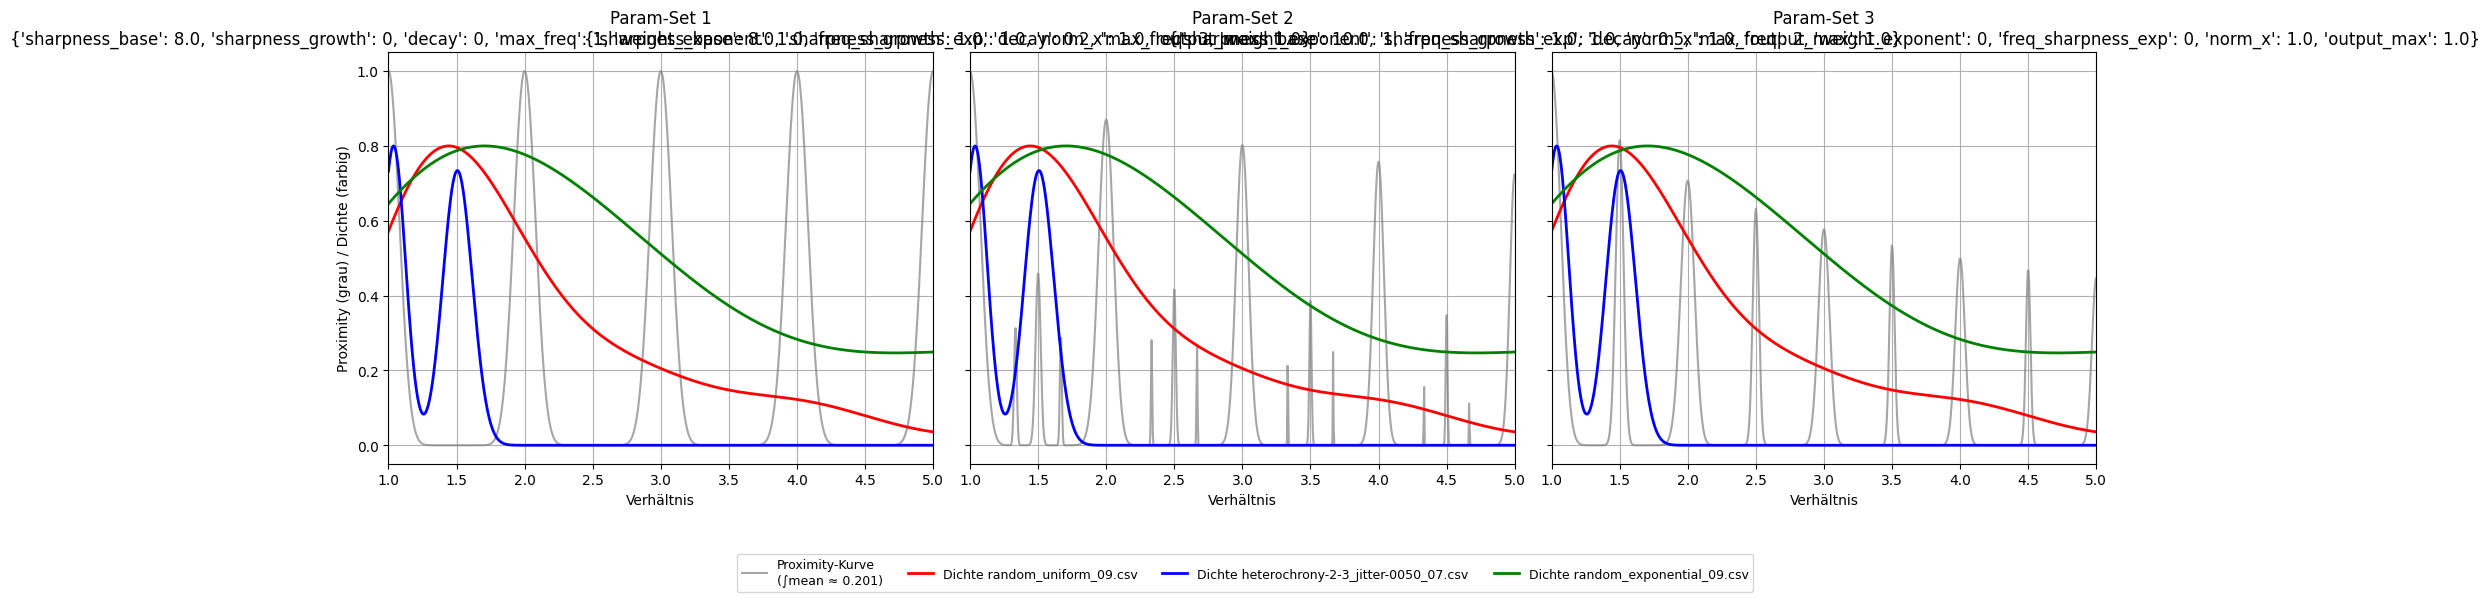

In [2]:
# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# Mehrere Parameter-Sets ausprobieren
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import simpson
from fractions import Fraction
from scipy.stats import gaussian_kde

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_exp)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Daten einlesen
# =============================
PAIR_THRESHOLD = 0.01
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats/")
filenames = ["random_uniform_09.csv",
             "heterochrony-2-3_jitter-0050_07.csv",
             "random_exponential_09.csv"] 
colors = ["red", "blue", "green"]

# =============================
# 4) Verschiedene Parameter-Sets definieren
# =============================
param_sets = [
    dict(sharpness_base=8.0, sharpness_growth=0, decay=0,
         max_freq=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=8.0, sharpness_growth=1.0, decay=0.2,
         max_freq=3, weight_exponent=1, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=1.0, decay=0.5,
         max_freq=2, weight_exponent=0, freq_sharpness_exp=0,
         norm_x=1.0, output_max=1.0)
]
# =============================
# 5) Alle Param-Sets analysieren & nebeneinander plotten
# =============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

legend_handles = []
legend_labels = []

for idx, (ax, params) in enumerate(zip(axes, param_sets), start=1):
    dfs = []
    for fname in filenames:
        seq_path = base_dir / fname
        if not seq_path.exists():
            raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")
        df = pd.read_csv(seq_path)
        iois = df["IOI"].dropna().values
        df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
        df_pairs["source"] = fname
        dfs.append(df_pairs)

    df_all = pd.concat(dfs, ignore_index=True)

    # --- Densityplot + Proximity-Kurve ---
    x_min = max(1.0, df_all["ratio"].min() * 0.95)
    x_max = df_all["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
    mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

    # Proximity-Kurve
    curve_handle, = ax.plot(
        x_range, y_curve,
        alpha=0.7, color="gray",
        label=f"Proximity-Kurve\n(∫mean ≈ {mean_prox:.3f})"
    )

    # Density-Plots für Ratios
    for fname, color in zip(filenames, colors):
        df_seq = df_all[df_all["source"] == fname]
        ratios = df_seq["ratio"].values
        if len(ratios) > 1:  # KDE braucht >1 Datenpunkte
            kde = gaussian_kde(ratios)
            y_kde = kde(x_range)
            y_kde = y_kde / y_kde.max() * y_curve.max() * 0.8
            h, = ax.plot(x_range, y_kde, color=color, lw=2, label=f"Dichte {fname}")
            # Nur im ersten Subplot Handles sammeln (damit Legende nicht x3 lang wird)
            if idx == 1:
                legend_handles.append(h)
                legend_labels.append(f"Dichte {fname}")

    ax.set_title(f"Param-Set {idx}\n{params}")
    ax.set_xlabel("Verhältnis")
    if idx == 1:
        ax.set_ylabel("Proximity (grau) / Dichte (farbig)")
    ax.set_xlim(1, 5)
    ax.grid(True)

    # Proximity-Kurve auch für Legende nur einmal merken
    if idx == 1:
        legend_handles.insert(0, curve_handle)
        legend_labels.insert(0, curve_handle.get_label())

# Gemeinsame Legende unten
fig.legend(
    legend_handles, legend_labels,
    loc="lower center", ncol=len(legend_labels),
    frameon=True, fontsize=9
)

plt.tight_layout(rect=[0, 0.12, 1, 1])  # Platz für Legende unten
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd

# Hilfsfunktion: IOI-Ratios bauen
def compute_ratios(iois):
    n = len(iois)
    return np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                      for j in range(n)] for i in range(n)])

def analyze_dataset(folder_path, params, level="sequence", num_sequences=500, seed=42):
    """
    Analysiere Rhythmen in einem Ordner von CSV-Dateien mit IOI-Daten.
    
    Args:
        folder_path (str): Ordner mit CSVs (müssen Spalten 'IOI','animal_ID','song_ID','filename' enthalten).
        params (dict): Parameter für proximity_max_freq().
        level (str): "sequence", "individual", "dataset"
        num_sequences (int): Anzahl Nullmodell-Simulationen.
        seed (int): Zufallsseed.
        
    Returns:
        DataFrame mit Kennzahlen (diff, zscore, pval) pro Objekt und Nullmodell.
    """
    rng = np.random.default_rng(seed)
    
    # === 1) Daten laden ===
    dfs = []
    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue
        df["filename"] = fname
        dfs.append(df)
    if not dfs:
        raise ValueError("Keine gültigen Sequenzen im Ordner gefunden.")
    data = pd.concat(dfs, ignore_index=True)
    
    # === 2) globale IOI-Basis für Nullmodelle ===
    all_iois = data["IOI"].dropna().values
    global_median = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)
    
    # === 3) Gruppierung festlegen ===
    if level == "sequence":
        groups = data.groupby("filename")
    elif level == "individual":
        groups = data.groupby("animal_ID")
    elif level == "dataset":
        groups = [("dataset", data)]
    else:
        raise ValueError("level muss 'sequence','song','individual' oder 'dataset' sein.")
    
    # === 4) Nullmodelle vorbereiten ===
    null_cache = { "expon": {}, "uniform": {}, "empirical": {} }
    
    results = []
    
    for group_id, df_group in groups:
        iois = df_group["IOI"].dropna().values
        n = len(iois)
        if n < 3:
            continue
        
        # Realwert berechnen
        ratios_real = compute_ratios(iois)
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        median_real = np.median(prox_mat_real[triu_idx])
        
        row = {"object": group_id, "real_median": median_real}
        
        # Nullmodelle: nur einmal pro n simulieren
        for model in ["expon", "uniform", "empirical"]:
            if n not in null_cache[model]:
                medians = []
                for _ in range(num_sequences):
                    if model == "expon":
                        sim_iois = rng.exponential(scale=global_median, size=n)
                    elif model == "uniform":
                        sim_iois = rng.uniform(global_min, global_max, size=n)
                    elif model == "empirical":
                        sim_iois = rng.choice(all_iois, size=n, replace=True)
                    ratios = compute_ratios(sim_iois)
                    prox_mat, _, _ = proximity_max_freq(ratios, **params)
                    triu_idx = np.triu_indices_from(prox_mat, k=1)
                    medians.append(np.median(prox_mat[triu_idx]))
                null_cache[model][n] = np.array(medians)
            
            medians_null = null_cache[model][n]
            mean_null = np.mean(medians_null)
            std_null = np.std(medians_null, ddof=1)
            
            zscore = (median_real - mean_null) / std_null if std_null > 0 else np.nan
            pval = (np.sum(medians_null >= median_real) + 1) / (len(medians_null) + 1)
            
            row[f"diff_{model}"] = median_real - mean_null
            row[f"zscore_{model}"] = zscore
            row[f"pval_{model}"] = pval
        
        results.append(row)
    
    return pd.DataFrame(results)

params = {
    "max_freq": 10,
    "sharpness_base": 5,
    "sharpness_growth": 1.2,
    "decay": 0.5,
    "weight_exponent": 1,
    "freq_sharpness_exp": 0.8,
}

mein_dataset_ordner = "../data/Kwa-Sounds Scorpaena spp"

df_seq = analyze_dataset(mein_dataset_ordner, params, level="sequence")
#df_ind  = analyze_dataset(mein_dataset_ordner, params, level="individual")
df_all  = analyze_dataset(mein_dataset_ordner, params, level="dataset")

print("Ergebnisse pro Sequenz:")
print(df_seq)
print("\nErgebnisse für gesamtes Dataset:")
print(df_all)

In [9]:

print("Ergebnisse pro Sequenz:")
print(df_seq)
print("\nErgebnisse für gesamtes Dataset:")
print(df_all)

Ergebnisse pro Sequenz:
         object  real_median  diff_expon  zscore_expon  pval_expon  \
0    KWA1-C.csv     0.039841    0.010334      0.215421    0.251497   
1      KWA1.csv     0.017821    0.000854      0.041315    0.347305   
2   KWA10-C.csv     0.043827    0.014321      0.298514    0.237525   
3     KWA10.csv     0.081577    0.058350      1.694226    0.069860   
4    KWA2-C.csv     0.001429   -0.028077     -0.585273    0.630739   
5      KWA2.csv     0.320294    0.297531      8.841077    0.001996   
6    KWA3-C.csv     0.000023   -0.029483     -0.614580    0.818363   
7      KWA3.csv     0.682529    0.627889      7.217891    0.001996   
8    KWA4-C.csv     0.035650    0.012887      0.382948    0.237525   
9      KWA4.csv     0.011604   -0.004827     -0.246677    0.437126   
10   KWA5-C.csv     0.140524    0.112617      2.319411    0.039920   
11     KWA5.csv     0.738317    0.698312     11.836530    0.001996   
12   KWA6-C.csv     0.146671    0.123444      3.584261    0.017964